## Session 22 - Optional Task (HeartDisesase Dataset)

In [1]:
'''
Data Loading & Preprocessing

Load the Credit Card Fraud Detection dataset.
Perform basic preprocessing and separate features and target.
'''

import pandas as pd

# Load the dataset
df = pd.read_csv("creditcard.csv")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:", df.shape)

# Separate Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

# Display shapes
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

First 5 Rows of Dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

       

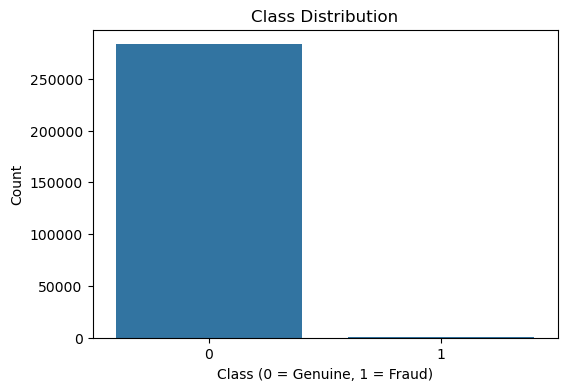

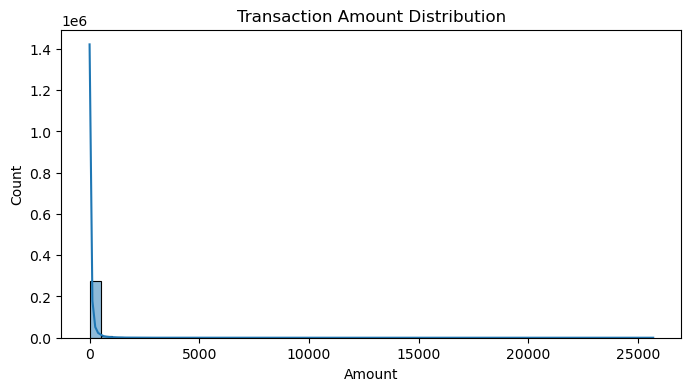

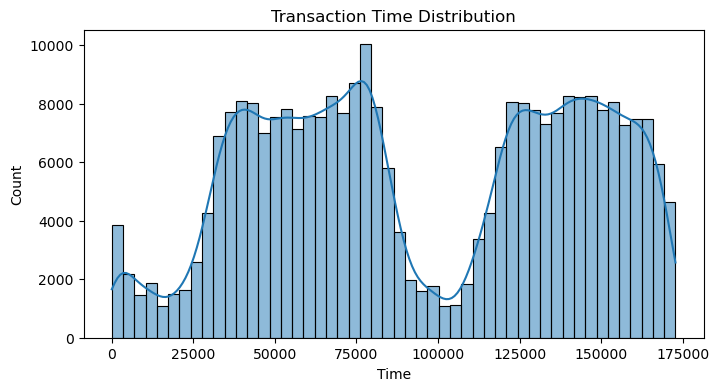

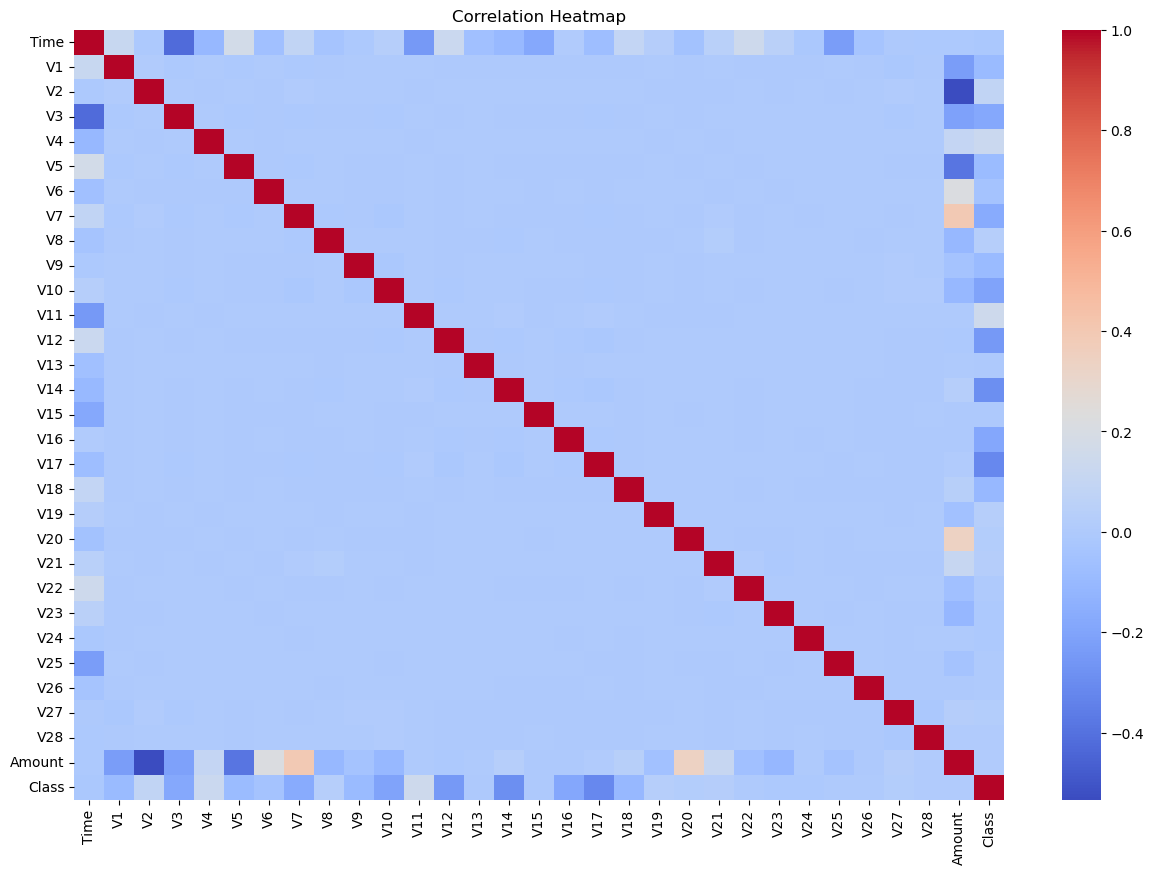

In [2]:
'''
Exploratory Data Analysis (EDA)
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# Transaction Amount Distribution
plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

# Transaction Time Distribution
plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [3]:
'''
Feature Scaling
'''

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale only Time and Amount columns
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [4]:
'''
Train-Test Split
'''

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Display shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (226980, 30)
X_test Shape : (56746, 30)
y_train Shape: (226980,)
y_test Shape : (56746,)


In [7]:
'''
Build and Train Logistic Regression Model
'''

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
'''
Make Predictions on Test Data
'''

# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 actual and predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


Confusion Matrix:
[[56650     6]
 [   42    48]]


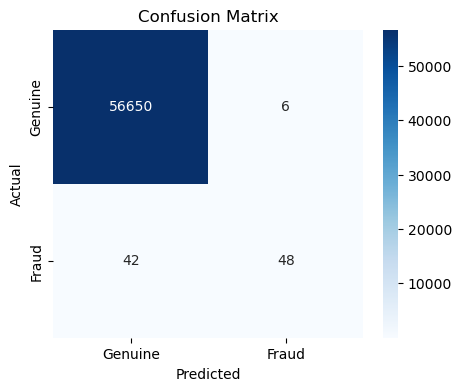

True Negatives (TN): 56650
False Positives (FP): 6
False Negatives (FN): 42
True Positives (TP): 48


In [9]:
'''
Confusion Matrix
'''

from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display heatmap
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Display TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives (TP):", TP)

In [10]:
'''
Model Evaluation
'''

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9992
Precision: 0.8889
Recall   : 0.5333
F1 Score : 0.6667

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.53      0.67        90

    accuracy                           1.00     56746
   macro avg       0.94      0.77      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [11]:
'''
Save Model and Preprocessing Objects
'''

import joblib

# Save model
joblib.dump(model, "fraud_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature columns
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Model and preprocessing objects saved successfully.")

Model and preprocessing objects saved successfully.


### Summary

- **Dataset Used**
  - Credit Card Fraud Detection Dataset

- **Data Preprocessing**
  - Loaded the dataset, removed duplicate transactions, checked for missing values, and applied Standard Scaling to the `Time` and `Amount` features.

- **Exploratory Data Analysis (EDA)**
  - Analyzed class distribution, visualized transaction distributions, and generated a correlation heatmap.

- **Machine Learning**
  - Built and trained a Logistic Regression model using a train-test split and evaluated it using multiple performance metrics.

- **Model Performance**
  - **Accuracy:** **⭐ 99.92%**
  - **Precision:** **88.89%**
  - **Recall:** **53.33%**
  - **F1-Score:** **66.67%**

- **Model Saving**
  - Saved the trained model, scaler, and feature columns using Joblib.

- **Model Testing**
  - Loaded the saved model and successfully tested it on sample transactions.